# Dynamic parameterization

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/BennettHydroLab/differentiable_modeling_workshop/blob/main/notebooks/applications/04_dynamic_parameterization.ipynb)

Here a network produces a degree-day melt factor at each timestep. A synthetic
twin experiment tests whether the known time-varying factor can be recovered;
a second experiment trains the same architecture against observed streamflow.

:::{admonition} Time check: 20 minutes
:class: tip
You will constrain dynamic parameters to physical ranges, separate synthetic
and observed targets, and identify when streamflow provides weak information
about an internal snow process.
:::

## Outline

1. Snow-bucket model and constant baseline
2. Time-varying parameter model
3. Synthetic twin experiment
4. Streamflow experiment
5. Learned-parameter diagnostics


In [1]:
# --- Colab bootstrap: installs the workshop package on first run -----------
try:
    import workshop_utils
except ImportError:
    %pip install -q "git+https://github.com/BennettHydroLab/differentiable_modeling_workshop.git"
    import workshop_utils

In [2]:
import copy
import math
import time

import numpy as np
import torch
import matplotlib.pyplot as plt

from workshop_utils import nse, summary, hydrograph, set_style, COLORS, ParamMap, MLP
from workshop_utils.data import (
    load_basin, split_by_water_year, BASIN_SNOWY, BASIN_LABELS,
)

set_style()
torch.manual_seed(0)

SPINUP = 365

## 1. Basin data and observation limits

Johnson Creek, Idaho, has a mean elevation of 2,156 m and receives 74% of its
precipitation as snow.

`minicamels` provides meteorological forcings and observed streamflow, but not
observed snow water equivalent (SWE) or evapotranspiration. The notebook
therefore uses two separate tests:

1. A synthetic twin experiment with known time-varying melt factor and
   pseudo-observed SWE.
2. Training against observed streamflow, where the internal snow states remain
   unobserved.

All SWE curves below are simulated, not measured. Lamichhane and Bennett train
against SWE observations; this notebook cannot reproduce that supervision
{cite}`lamichhane2025dynamic`.


In [3]:
ds = load_basin(BASIN_SNOWY)


def block(test_years):
    return split_by_water_year(ds, train=(1998, 1999), test=test_years, spinup_days=SPINUP)


def arrays(d):
    return dict(
        P=torch.tensor(d.prcp.values, dtype=torch.float32),
        T=torch.tensor(d.tmean.values, dtype=torch.float32),
        E=torch.tensor(d.pet.values, dtype=torch.float32),
        R=torch.tensor(d.srad.values, dtype=torch.float32),
        Q=torch.tensor(d.qobs.values, dtype=torch.float32),
        doy=torch.tensor(d.time.dt.dayofyear.values, dtype=torch.float32),
        time=d.time.values,
    )


train = arrays(block((2000, 2001))["train"])    # WY1998-1999
val = arrays(block((2000, 2001))["test"])       # WY2000-2001
test = arrays(block((2002, 2004))["test"])      # WY2002-2004

print(BASIN_LABELS[BASIN_SNOWY])
print(f"mean air temperature : {float(train['T'].mean()):5.2f} degC")
print(f"days below freezing  : {float((train['T'] < 0).float().mean()) * 100:5.1f} %")
print(f"train / val / test   : {len(train['P'])} / {len(val['P'])} / {len(test['P'])} days")

Johnson Creek, ID (snow dominated)
mean air temperature :  1.84 degC
days below freezing  :  47.2 %
train / val / test   : 1095 / 1096 / 1461 days


## 2. Snow-bucket model

Same HBV-lite as `03_hybrid_bucket_model`, with a degree-day snow store bolted
on the front. Two new parameters, so eight in total:

| Parameter | Meaning | Range used here |
|---|---|---|
| `T_snow` | rain/snow partition temperature | -3 to 3 °C |
| `DDF` | degree-day melt factor | 0.5 to 8 mm °C⁻¹ d⁻¹ |

**Where that `DDF` range comes from.** SNOW-17 as published works on a 6-hourly
timestep, with `MFMAX` in 0.6-2.5 and `MFMIN` in 0.05-0.59 mm °C⁻¹ (6h)⁻¹
{cite}`lamichhane2025dynamic,anderson2006snow17`. `minicamels` is daily, so
multiply by four: 2.4-10.0 and 0.2-2.4 mm °C⁻¹ d⁻¹. Our single daily range of
0.5-8 spans both. We state the conversion rather than hide it, because a
6-hourly melt factor used as a daily one is off by 4x, and that gives you a
well-calibrated model of the wrong thing.

Two differentiability details in the code below, both of them
`research_brief.md` §6 pitfall 3:

- Rain/snow partitioning is a **smooth** sigmoid ramp rather than
  `if T < T_snow`. As the brief points out, SNOW-17's own `PXTEMP1`/`PXTEMP2`
  scheme is already a linear ramp, so hydrologists have been writing smooth
  relaxations for decades without calling them that.
- Melt is capped at available snowpack with `SWE * (1 - exp(-melt_pot / SWE))`
  rather than `min(melt_pot, SWE)`. `smooth_min` would be the natural tool, but
  its log-sum-exp form undershoots by about `log(2)/beta`, and undershooting
  zero means *negative melt* on a bare-ground day. The exponential form is
  exactly 0 when either argument is 0, never exceeds `SWE`, and keeps a live
  gradient on both sides. It costs about 2% accuracy when the pack is deep and
  melt is small; we call that good enough and move on.

In [4]:
PARAM_NAMES = ["FC", "beta", "LP", "K_fast", "K_slow", "PERC", "T_snow", "DDF"]

LO = torch.tensor([  50., 1.0, 0.3, 0.05, 0.001, 0.1, -3.0, 0.5])
HI = torch.tensor([1000., 6.0, 1.0, 0.60, 0.200, 5.0,  3.0, 8.0])
pmap = ParamMap(LO, HI)

# The melt factor gets its own range-map, because a network will be emitting it.
DDF_LO, DDF_HI = 0.5, 8.0
ddf_map = ParamMap([DDF_LO], [DDF_HI])


def simulate(P, T, E, theta, net=None, X=None, ddf_series=None, keep=False):
    """Degree-day snow + HBV-lite.

    theta       : (n, 8) physical parameters
    net, X      : NN_phi and its standardized inputs; DDF emitted each timestep
    ddf_series  : (n, time) a prescribed time-varying DDF (used for the twin)
    returns     : (time, n) discharge; with keep=True also SWE and the DDF used
    """
    FC, beta, LP, K_fast, K_slow, PERC, T_snow, DDF = theta.T
    n = theta.shape[0]

    # u = (SWE, soil store, fast reservoir, slow reservoir)
    SWE = torch.zeros(n)
    S_soil = torch.full((n,), 50.)
    S_fast = torch.full((n,), 5.)
    S_slow = torch.full((n,), 20.)

    q_out, swe_out, ddf_out = [], [], []
    for t in range(P.shape[0]):
        # Smooth rain/snow partition: a sigmoid ramp 0.7 degC wide.
        f_snow = torch.sigmoid(-(T[t] - T_snow) / 0.7)
        snowfall = P[t] * f_snow
        rain = P[t] - snowfall

        # --- theta_t: the one quantity that is allowed to vary in time --------
        if net is not None:
            z = torch.cat([X[t].unsqueeze(0).expand(n, -1), (SWE / 100.).unsqueeze(-1)], -1)
            ddf = ddf_map(net(z)).squeeze(-1)
        elif ddf_series is not None:
            ddf = ddf_series[:, t]
        else:
            ddf = DDF * torch.ones(n)
        # ---------------------------------------------------------------------

        melt_pot = ddf * torch.nn.functional.softplus(T[t], beta=2.0)
        melt = SWE * (1 - torch.exp(-melt_pot / (SWE + 1e-3)))
        SWE = SWE + snowfall - melt

        P_in = rain + melt

        wetness = torch.clamp(S_soil / FC, 0., 1.)
        recharge = P_in * wetness ** beta
        et = E[t] * torch.clamp(S_soil / (LP * FC), 0., 1.)
        S_soil = torch.clamp(S_soil + P_in - recharge - et, min=0.)

        perc = torch.minimum(PERC, S_fast)
        S_fast = S_fast + recharge - perc
        q_fast = K_fast * S_fast
        S_fast = S_fast - q_fast

        S_slow = S_slow + perc
        q_slow = K_slow * S_slow
        S_slow = S_slow - q_slow

        q_out.append(q_fast + q_slow)
        swe_out.append(SWE)
        ddf_out.append(ddf)

    Q = torch.stack(q_out)
    if keep:
        return Q, torch.stack(swe_out), torch.stack(ddf_out)
    return Q

## 3. Constant-parameter baseline

All eight parameters are calibrated against streamflow on WY1998-1999.
Validation uses WY2000-2001 and final metrics use WY2002-2004.


In [5]:
t0 = time.time()

raw_const = torch.zeros(1, 8, requires_grad=True)
opt = torch.optim.Adam([raw_const], lr=0.25)

for step in range(30):
    opt.zero_grad()
    q_sim = simulate(train["P"], train["T"], train["E"], pmap(raw_const))[:, 0]
    loss = -nse(q_sim[SPINUP:], train["Q"][SPINUP:])
    loss.backward()
    opt.step()
    if step % 10 == 0:
        print(f"  step {step:3d}   train NSE {-loss.item():.3f}")

t_const = time.time() - t0
raw_const = raw_const.detach()
theta_const = pmap(raw_const)

print(f"\n30 steps in {t_const:.1f} s   final train NSE {-loss.item():.3f}")
for name, value in zip(PARAM_NAMES, theta_const[0].tolist()):
    print(f"  {name:8s} {value:8.3f}")

  step   0   train NSE -1.013


  step  10   train NSE 0.749


  step  20   train NSE 0.850



30 steps in 39.5 s   final train NSE 0.886
  FC        939.971
  beta        1.071
  LP          0.377
  K_fast      0.100
  K_slow      0.031
  PERC        4.715
  T_snow     -2.942
  DDF         3.126


In [6]:
def score(d, theta, net=None, X=None):
    with torch.no_grad():
        q = simulate(d["P"], d["T"], d["E"], theta, net=net, X=X)[:, 0]
    return summary(q[SPINUP:], d["Q"][SPINUP:])


m_const_val = score(val, theta_const)
m_const_test = score(test, theta_const)
print(f"validation NSE  {m_const_val['NSE']:.3f}")
print(f"test NSE        {m_const_test['NSE']:.3f}   KGE {m_const_test['KGE']:.3f}")

validation NSE  0.839
test NSE        0.363   KGE 0.450


Note the drop. Validation scores well; the test block does not. WY2003 is a hard
year at this gauge for a model this simple, and both models in this notebook
will struggle with it. It is worth seeing, because it is what a real held-out
evaluation looks like when you do not get to choose the years.

## 4. $\theta$ becomes a function

Canonical form **(1)** from `research_brief.md` §1:

$$\frac{d\mathbf{u}}{dt} = f\big(\mathbf{u}, \mathbf{x}, \mathrm{NN}_\varphi(\mathbf{x}, \mathbf{a}, \mathbf{u}), t\big)$$

and in the discrete daily form the code actually runs,

$$\theta_t = \hat{g}\big(\mathrm{NN}_\varphi(\mathbf{x}_t, \mathbf{u}_t)\big), \qquad
\mathbf{u}_{t+1} = \mathbf{u}_t + \Delta t \, f(\mathbf{u}_t, \mathbf{x}_t, \theta_t)$$

where $\hat{g}$ is the sigmoid range-map, `ParamMap`, which keeps $\theta_t$
inside the published bounds no matter what the network says. This is taxonomy
design **B**.

**What the network sees.** Four inputs: today's mean temperature, incoming
shortwave radiation, precipitation, and the model's own current snow water
equivalent. Three of those are forcings; the fourth is a *state*, which is the
detail that makes this a hybrid model rather than a pre-processor. The network
is reading the physics' internal variables as the simulation runs.

**What the network deliberately does not see: day of year.** If we handed it the
calendar and then showed you that it learned a seasonal cycle, we would have
shown you nothing. Making it infer season from weather is a real test.

:::{admonition} Two simplifications
:class: note
Lamichhane & Bennett use a 1-layer LSTM with 64 hidden units over a 365-day
lookback, emitting eight parameters. We use a 2x16 MLP on the current day's
forcings plus one state, emitting one parameter. The reason is arithmetic: an
LSTM unrolled inside a 1,095-step water balance would put this cell far outside
the workshop's 60-second-per-cell budget.

There is a cost. Our network has no memory of last week's weather, so it cannot
represent "the pack has been ripening for a fortnight." The LSTM can, and that
is one of the reasons the paper uses one.
:::

In [7]:
def standardize(d, stats=None):
    """Network inputs on a common scale, using TRAINING statistics only."""
    X = torch.stack([d["T"], d["R"] / 100., d["P"]], -1)
    if stats is None:
        stats = (X.mean(0, keepdim=True), X.std(0, keepdim=True).clamp_min(1e-6))
    return (X - stats[0]) / stats[1], stats


X_train, stats = standardize(train)
X_val, _ = standardize(val, stats)
X_test, _ = standardize(test, stats)


def warm_start(net, X, ddf_target, steps=300):
    """Pre-train NN_phi to emit a constant DDF, so the hybrid starts at the physics.

    This is research_brief.md pitfall 4. Kalauni et al. do the same thing with
    5,000 supervised steps against the physics formula's own output; ours is a
    constant, so 300 is plenty and it costs under a second.
    """
    target = ddf_map.inverse(torch.tensor([[ddf_target]])).squeeze()
    z = torch.cat([X, torch.zeros(len(X), 1)], -1)
    opt = torch.optim.Adam(net.parameters(), lr=1e-2)
    for _ in range(steps):
        opt.zero_grad()
        loss = ((net(z).squeeze(-1) - target) ** 2).mean()
        loss.backward()
        opt.step()
    return float(loss.detach())

## 5. Synthetic twin experiment

The calibrated model is driven by a known seasonal degree-day factor,

$$\mathrm{DDF}(t)=\frac{M_{max}+M_{min}}{2}+
\frac{M_{max}-M_{min}}{2}\sin\!\left(\frac{2\pi(\mathrm{doy}-81)}{366}ight).$$

The resulting SWE is treated as a synthetic target. Because the generating
function is known, recovery can be evaluated directly. The network does not
receive day of year.


In [8]:
MF_MAX, MF_MIN = 5.5, 1.2


def ddf_true(doy):
    return (MF_MAX + MF_MIN) / 2 + (MF_MAX - MF_MIN) / 2 * torch.sin(2 * math.pi * (doy - 81) / 366.)


with torch.no_grad():
    _, swe_true_train, _ = simulate(train["P"], train["T"], train["E"], theta_const,
                                    ddf_series=ddf_true(train["doy"]).unsqueeze(0), keep=True)
    _, swe_true_test, _ = simulate(test["P"], test["T"], test["E"], theta_const,
                                   ddf_series=ddf_true(test["doy"]).unsqueeze(0), keep=True)
swe_true_train = swe_true_train[:, 0]
swe_true_test = swe_true_test[:, 0]

print(f"synthetic peak SWE: {float(swe_true_train.max()):.0f} mm  (SIMULATED, not observed)")

synthetic peak SWE: 876 mm  (SIMULATED, not observed)


### Constant baseline

Before asking whether the network recovers the sinusoid, find out how much
recovering it is worth. Fit a single constant `DDF` to the synthetic SWE, with
every other parameter given away for free at its true value.

In [9]:
t0 = time.time()
raw_ddf = torch.zeros(1, 1, requires_grad=True)
opt = torch.optim.Adam([raw_ddf], lr=0.2)

for step in range(20):
    opt.zero_grad()
    theta_t = torch.cat([theta_const[:, :7], ddf_map(raw_ddf)], 1)
    _, swe_sim, _ = simulate(train["P"], train["T"], train["E"], theta_t, keep=True)
    loss = 1 - nse(swe_sim[SPINUP:, 0], swe_true_train[SPINUP:])
    loss.backward()
    opt.step()

ddf_best_const = float(ddf_map(raw_ddf).detach()[0, 0])
print(f"best constant DDF : {ddf_best_const:.2f} mm/degC/day  ({time.time()-t0:.1f} s)")
print(f"SWE NSE           : {1 - loss.item():.4f}")
print(f"true DDF range    : {MF_MIN:.2f} to {MF_MAX:.2f}")

best constant DDF : 4.37 mm/degC/day  (13.4 s)
SWE NSE           : 0.9975
true DDF range    : 1.20 to 5.50


A single constant reproduces the synthetic SWE with NSE above 0.99.

Keep that number in mind. It is why this field needs process-specific
diagnostics: an aggregate score on the state variable cannot see the thing we
are trying to learn. It is also Lamichhane & Bennett's finding in the paper.
KGE could not separate their hybrid from a pure LSTM, but melt-out duration
separated them by nearly two weeks (hybrid +1.0 days against the LSTM's +11.75
days). In their words, "traditional metrics may not fully capture physically
meaningful improvements."

So the criterion below is whether the network recovers the function, not the SWE
NSE it achieves.

In [10]:
torch.manual_seed(0)
net_twin = MLP(n_in=4, n_out=1, hidden=16, depth=2)
warm_start(net_twin, X_train, ddf_best_const)

opt = torch.optim.Adam(net_twin.parameters(), lr=2e-2)
t0 = time.time()
for step in range(30):
    opt.zero_grad()
    _, swe_sim, _ = simulate(train["P"], train["T"], train["E"], theta_const,
                             net=net_twin, X=X_train, keep=True)
    loss = 1 - nse(swe_sim[SPINUP:, 0], swe_true_train[SPINUP:])
    loss.backward()
    torch.nn.utils.clip_grad_norm_(net_twin.parameters(), 1.0)
    opt.step()
    if step % 10 == 0:
        print(f"  step {step:3d}   SWE NSE {1 - loss.item():.4f}")

t_twin = time.time() - t0
print(f"\n30 steps in {t_twin:.1f} s ({t_twin/30:.2f} s/step)")

  step   0   SWE NSE 0.9976


  step  10   SWE NSE 0.9982


  step  20   SWE NSE 0.9988



30 steps in 34.7 s (1.16 s/step)


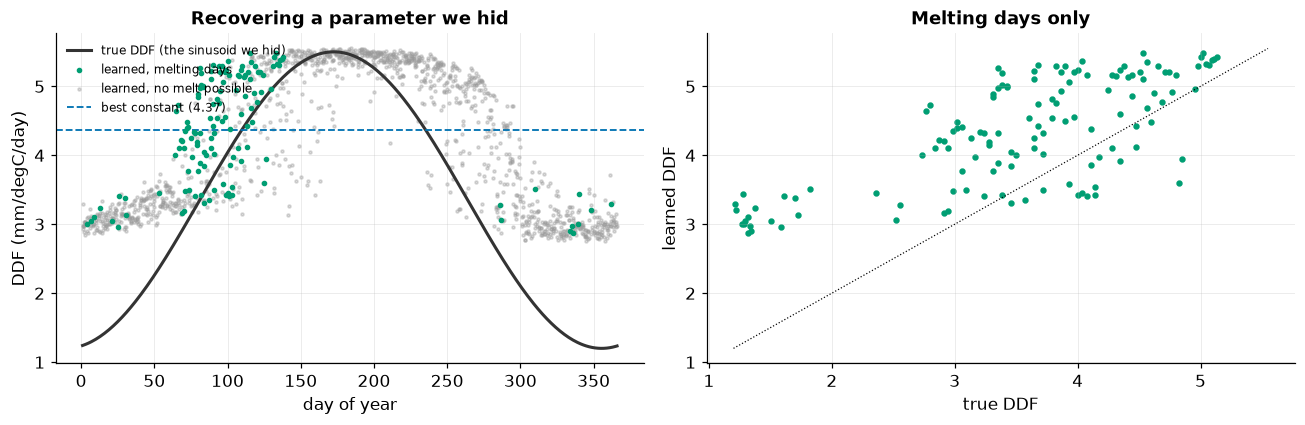

correlation with the hidden function, all days : 0.876
                              on melting days  : 0.720  (n = 131)
learned range 2.75 to 5.55  (true 1.20 to 5.50)


In [11]:
with torch.no_grad():
    _, swe_hat, ddf_hat = simulate(test["P"], test["T"], test["E"], theta_const,
                                   net=net_twin, X=X_test, keep=True)
ddf_hat = ddf_hat[:, 0]
ddf_ref = ddf_true(test["doy"])

# The melt factor only does anything when there is snow AND it is above freezing.
melting = (test["T"] > 0) & (swe_hat[:, 0] > 5)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

order = torch.argsort(test["doy"])
ax1.plot(test["doy"][order], ddf_ref[order], color=COLORS["obs"], lw=2,
         label="true DDF (the sinusoid we hid)")
ax1.scatter(test["doy"][melting], ddf_hat[melting], s=7, color=COLORS["hybrid"],
            label="learned, melting days", zorder=3)
ax1.scatter(test["doy"][~melting], ddf_hat[~melting], s=4, color="0.6", alpha=0.35,
            label="learned, no melt possible")
ax1.axhline(ddf_best_const, color=COLORS["physics"], ls="--", lw=1.2,
            label=f"best constant ({ddf_best_const:.2f})")
ax1.set_xlabel("day of year")
ax1.set_ylabel("DDF (mm/degC/day)")
ax1.set_title("Recovering a parameter we hid")
ax1.legend(fontsize=8, loc="upper left")

ax2.scatter(ddf_ref[melting], ddf_hat[melting], s=10, color=COLORS["hybrid"])
lims = [float(min(ddf_ref.min(), ddf_hat.min())), float(max(ddf_ref.max(), ddf_hat.max()))]
ax2.plot(lims, lims, color="k", lw=0.8, ls=":")
ax2.set_xlabel("true DDF")
ax2.set_ylabel("learned DDF")
ax2.set_title("Melting days only")
plt.tight_layout()
plt.show()

r_all = float(np.corrcoef(ddf_hat.numpy(), ddf_ref.numpy())[0, 1])
r_melt = float(np.corrcoef(ddf_hat[melting].numpy(), ddf_ref[melting].numpy())[0, 1])
print(f"correlation with the hidden function, all days : {r_all:.3f}")
print(f"                              on melting days  : {r_melt:.3f}  (n = {int(melting.sum())})")
print(f"learned range {float(ddf_hat.min()):.2f} to {float(ddf_hat.max()):.2f}  "
      f"(true {MF_MIN:.2f} to {MF_MAX:.2f})")

The figure contains both a success and a limit.

**The success.** The network was never shown the calendar, and it recovered a
seasonal cycle anyway, peaking in mid-summer at close to the right amplitude at
the top. It got there through radiation and temperature, the quantities
SNOW-17's sinusoid was standing in for in the first place. Compare it to the
flat blue line: a constant melt factor scores well on SWE and is wrong by a
factor of three in April.

**The limit.** Look at the grey points. In midwinter the learned DDF wanders and
does not find the low `MFMIN` end of the true curve. That follows from the
structure of the model. On a day with no melt, the melt factor multiplies zero.
It has no effect on the simulation, so the loss has no opinion about it, so the
gradient reaching the network is zero. The parameter is *not identified* there.

The useful statement is that a dynamic parameterization learns $\theta_t$ **only
where the data constrain it**, and the rest is whatever the network's smoothness
prior happens to produce. Beven's equifinality argument
{cite}`beven2006manifesto` does not go away when you make $\theta$ a function.
If anything, a time-varying parameter introduces a great deal of new freedom,
and Lamichhane & Bennett's own caveat is that their hybrid "does not impose
strict mass-balance constraints" for this reason.

## 6. Streamflow training

The twin told us the machinery works and where it stops working. Now point it at
data we did not manufacture, observed discharge, and let both the network and
the remaining seven physical parameters train together.

In [12]:
torch.manual_seed(0)
net_real = MLP(n_in=4, n_out=1, hidden=16, depth=2)
warm_start(net_real, X_train, float(theta_const[0, 7]))

raw_dyn = pmap.inverse(theta_const).clone().requires_grad_(True)
phi = list(net_real.parameters())
opt = torch.optim.Adam([
    {"params": [raw_dyn], "lr": 0.1},
    {"params": phi,       "lr": 5e-3},
])

history, best = [], (-np.inf, None, 0)
t0 = time.time()
for step in range(20):
    opt.zero_grad()
    q_sim = simulate(train["P"], train["T"], train["E"], pmap(raw_dyn),
                     net=net_real, X=X_train)[:, 0]
    loss = -nse(q_sim[SPINUP:], train["Q"][SPINUP:])
    loss.backward()
    torch.nn.utils.clip_grad_norm_([raw_dyn] + phi, 1.0)
    opt.step()

    v = score(val, pmap(raw_dyn).detach(), net=net_real, X=X_val)["NSE"]
    history.append((-loss.item(), v))
    if v > best[0]:
        best = (v, (raw_dyn.detach().clone(), copy.deepcopy(net_real)), step + 1)
    if step % 5 == 0:
        print(f"  step {step:3d}   train NSE {-loss.item():.3f}   val NSE {v:.3f}")

t_dyn = time.time() - t0
raw_dyn_best, net_dyn = best[1]
theta_dyn = pmap(raw_dyn_best)
print(f"\n20 steps in {t_dyn:.1f} s ({t_dyn/20:.2f} s/step)")
print(f"best validation NSE {best[0]:.3f} at step {best[2]}")

  step   0   train NSE 0.889   val NSE 0.816


  step   5   train NSE 0.902   val NSE 0.824


  step  10   train NSE 0.910   val NSE 0.861


  step  15   train NSE 0.920   val NSE 0.874



20 steps in 47.5 s (2.37 s/step)
best validation NSE 0.904 at step 20


In [13]:
m_dyn_test = score(test, theta_dyn, net=net_dyn, X=X_test)

print(f"{'':10s}{'constant':>12s}{'dynamic':>12s}{'change':>10s}")
print("-" * 44)
for key in m_const_test:
    print(f"{key:10s}{m_const_test[key]:12.3f}{m_dyn_test[key]:12.3f}"
          f"{m_dyn_test[key] - m_const_test[key]:+10.3f}")

              constant     dynamic    change
--------------------------------------------
NSE              0.363       0.448    +0.086
KGE              0.450       0.497    +0.047
logNSE           0.492       0.447    -0.045
PBIAS           -4.167      -7.297    -3.129
RMSE             1.674       1.557    -0.117


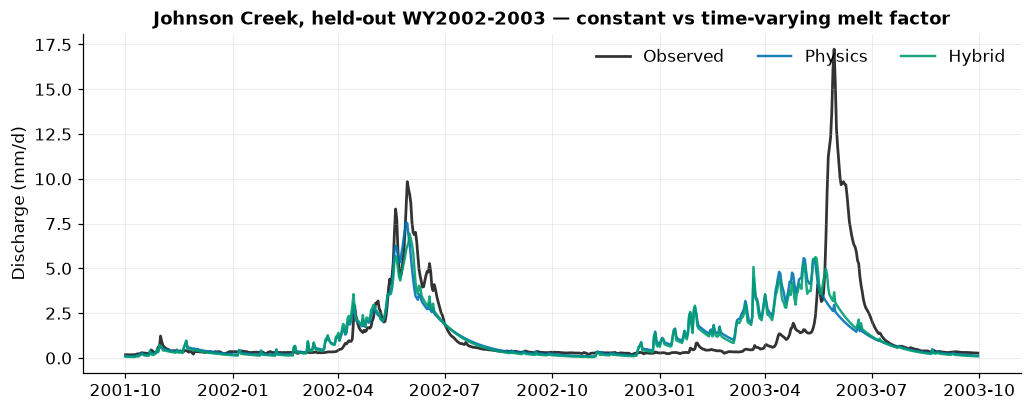

In [14]:
with torch.no_grad():
    q_const = simulate(test["P"], test["T"], test["E"], theta_const)[:, 0]
    q_dyn, swe_dyn, ddf_dyn = simulate(test["P"], test["T"], test["E"], theta_dyn,
                                       net=net_dyn, X=X_test, keep=True)
    q_dyn = q_dyn[:, 0]

show = slice(SPINUP, SPINUP + 730)
hydrograph(
    test["time"][show],
    obs=test["Q"][show].numpy(),
    physics=q_const[show].numpy(),
    hybrid=q_dyn[show].numpy(),
    title="Johnson Creek, held-out WY2002-2003 — constant vs time-varying melt factor",
)
plt.show()

:::{admonition} A mixed result, reported as one
:class: warning
NSE, KGE and RMSE improve; **log-NSE and percent bias get worse.** The dynamic
model gains most of its ground on the spring freshet, the largest flows of the
year and the ones NSE weights, and gives some back on low flows and on the
overall water balance.

That pattern should look familiar by now. We optimized a variance-based loss, it
improved the variance-based scores, and the quantities it was blind to drifted.
Kalauni et al. document the sharper version at unseen sites: their hybrids
capture the diurnal cycle of latent heat and *lose* the long-term evaporative
index to per-site-calibrated physics, Spearman rho 0.88 against 0.68
{cite}`kalauni2025hybrid`. They are explicit that a variance-based training
objective is part of the explanation, and equally explicit that it is not the
whole of it.
:::

## 7. Learned parameter

The interpretability claim is only worth something if you cash it in. The
learned parameter is one number per day, so plot it: against the season, and
against the variables it was given.

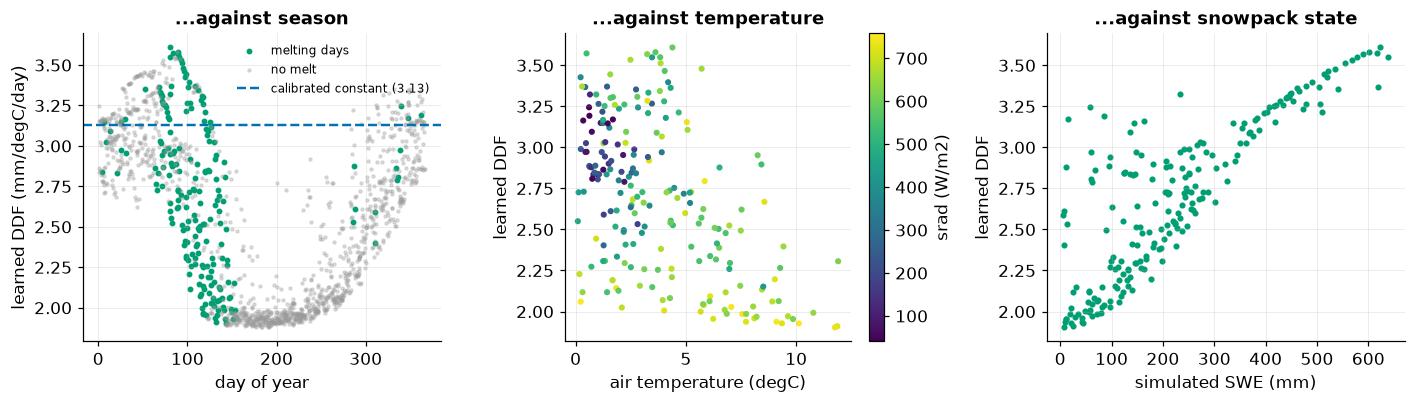

learned DDF on melting days: min 1.90  median 2.72  max 3.61
calibrated constant        : 3.13

what the learned melt factor tracks, on melting days:
  corr(DDF, day of year   ) = -0.191
  corr(DDF, radiation     ) = -0.441
  corr(DDF, temperature   ) = -0.523
  corr(DDF, simulated SWE ) = +0.827


In [15]:
ddf_dyn = ddf_dyn[:, 0]
melting_real = (test["T"] > 0) & (swe_dyn[:, 0] > 5)

fig, axes = plt.subplots(1, 3, figsize=(13, 3.8))

axes[0].scatter(test["doy"][melting_real], ddf_dyn[melting_real], s=8,
                color=COLORS["hybrid"], label="melting days")
axes[0].scatter(test["doy"][~melting_real], ddf_dyn[~melting_real], s=4,
                color="0.6", alpha=0.3, label="no melt")
axes[0].axhline(float(theta_const[0, 7]), color=COLORS["physics"], ls="--",
                label=f"calibrated constant ({float(theta_const[0,7]):.2f})")
axes[0].set_xlabel("day of year"); axes[0].set_ylabel("learned DDF (mm/degC/day)")
axes[0].set_title("...against season")
axes[0].legend(fontsize=8)

sc = axes[1].scatter(test["T"][melting_real], ddf_dyn[melting_real], s=9,
                     c=test["R"][melting_real].numpy(), cmap="viridis")
axes[1].set_xlabel("air temperature (degC)"); axes[1].set_ylabel("learned DDF")
axes[1].set_title("...against temperature")
plt.colorbar(sc, ax=axes[1], label="srad (W/m2)")

axes[2].scatter(swe_dyn[melting_real, 0], ddf_dyn[melting_real], s=9,
                color=COLORS["hybrid"])
axes[2].set_xlabel("simulated SWE (mm)"); axes[2].set_ylabel("learned DDF")
axes[2].set_title("...against snowpack state")
plt.tight_layout()
plt.show()

print(f"learned DDF on melting days: min {float(ddf_dyn[melting_real].min()):.2f}  "
      f"median {float(ddf_dyn[melting_real].median()):.2f}  "
      f"max {float(ddf_dyn[melting_real].max()):.2f}")
print(f"calibrated constant        : {float(theta_const[0, 7]):.2f}\n")


def corr(a, b):
    return float(np.corrcoef(a.numpy(), b.numpy())[0, 1])


print("what the learned melt factor tracks, on melting days:")
for label, series in [("day of year", test["doy"]), ("radiation", test["R"]),
                      ("temperature", test["T"]), ("simulated SWE", swe_dyn[:, 0])]:
    print(f"  corr(DDF, {label:14s}) = {corr(ddf_dyn[melting_real], series[melting_real]):+.3f}")

This is not what the twin experiment found.

Trained against **synthetic SWE**, the network recovered a seasonal cycle keyed
to radiation, the signal SNOW-17's sinusoid was invented to stand in for.
Trained against **observed streamflow**, it did something else entirely. The
strongest relationship by far is with the model's own simulated snowpack
(correlation around +0.8): the learned melt factor is largest when the pack is
deep and cold, and falls as the pack thins and the air warms. The correlation
with radiation is *negative*, and with day of year it is close to nothing.

Two readings, and you need both.

**The generous one.** A pack-state dependence is a reasonable thing to ask for.
A deep midwinter pack behaves differently from a thin ripening one: it has cold
content to overcome, and it holds liquid water. SNOW-17 represents these with
its antecedent-temperature index `TIPM`, its negative melt factor `NMF`, and its
liquid-water holding capacity `PLWHC`. Our degree-day model has none of those.
So one reading is that the network, given one knob and a process that needs
three, used the knob to reach for the missing pack-state physics, which would be
a diagnostic finding of the kind `05_hybrid_as_diagnostic` is built around.

**The skeptical one, which you should hold at least as firmly.** SWE here is a
*simulated state*, not an observation. A learned parameter that tracks a
simulated state can just as easily be compensating for an error somewhere else,
in the rain/snow partition, in PET, or in the soil store. Streamflow at a gauge
is an indirect constraint on what a snowpack is doing, and this is what "only
weakly identified" looks like in practice
{cite}`shen2023differentiable,jiang2020improving`.

The summary is that the dynamic parameterization improved the hydrograph and did
**not** deliver a trustworthy statement about snow physics. We know that only
because the twin experiment showed us what a *successful* recovery looks like on
the same architecture, same basin, same forcings. Without it we would have had a
plausible story and no way to check it.

This is also, in miniature, why Lamichhane & Bennett trained against SWE at 734
SNOTEL sites rather than against streamflow. If you want to learn snow physics,
you need snow observations.

## Your turn

**Exercise 1 (3 minutes).** Give the network day-of-year as a fifth input
(`sin` and `cos` of `2*pi*doy/366`, so it is continuous at New Year). Does the
twin recovery improve? Does the streamflow test score?

**Exercise 2 (5 minutes).** Emit *two* parameters instead of one, letting
`T_snow` vary in time as well as `DDF`. `ParamMap` takes vectors, so this is a
two-line change. Look at the two learned series together before you look at the
score.

:::{dropdown} Solution: Exercise 1
Add to `standardize`: `torch.sin(2*math.pi*d["doy"]/366)` and the matching
cosine, and change `MLP(n_in=4, ...)` to `n_in=6`.

Twin recovery improves noticeably, including in midwinter, because the network
can now interpolate the seasonal shape across days where the gradient told it
nothing. The streamflow test score barely moves.

Both halves matter. The first says the recovery experiment was measuring
something real, since making the task easier makes the answer better. The second
says the calendar was not the binding constraint on streamflow skill, and it
carries a warning: a model that can express a seasonal cycle directly may
express one whether or not the physics calls for it, which makes the learned
function less diagnostic rather than more. Lamichhane & Bennett's network gets
latitude and elevation but not date, for related reasons.
:::

:::{dropdown} Solution: Exercise 2
```python
theta_map2 = ParamMap([-3.0, 0.5], [3.0, 8.0])   # T_snow, DDF
net = MLP(n_in=4, n_out=2, hidden=16, depth=2)
# inside the time loop:
dyn = theta_map2(net(z))
T_snow_t, ddf = dyn[:, 0], dyn[:, 1]
```

Training NSE improves a little. The learned `T_snow` series is much less
interpretable than the melt factor. It tends to drift with the seasons in a way
that has no clean physical reading, because rain/snow partitioning and melt are
substitutes for each other over a season: a warmer threshold and a slower melt
can produce nearly the same hydrograph as a colder threshold and a faster one.

That is equifinality, and it is the argument for Lamichhane & Bennett's choice
to hold `NMF` and `MBASE` fixed at published values rather than letting the
network emit all ten SNOW-17 parameters. More learnable parameters does not mean
more insight. Choose which ones on the basis of a sensitivity analysis, as they
did, following He et al. (2011).
:::

## Takeaways

- `ParamMap` keeps a dynamic parameter within its physical range at every step.
- The twin experiment recovered the imposed seasonal melt factor on active
  melt days.
- Streamflow alone weakly identifies the internal melt process, so simulated
  SWE and the learned parameter are hypotheses rather than observations.
## Where next

Notebook `05_hybrid_as_diagnostic` compares several closure locations under a
controlled training protocol.
## References

```{bibliography}
:filter: docname in docnames
```